# 公式 o9 — How to Use the Unit System（単位系）

> **出典（E-Cell4 公式）**: Examples / example12 — https://ecell4.e-cell.org/examples/example12.html
>
> パラメータに**物理単位**を付けて、単位変換・次元チェックをしながらモデルを書く方法。
>
> **公式からの変更点**: 単位機能は `pint` に依存する。本リポジトリでは `uv add pint` で導入済み
> （未導入だと `ecell4.extra.unit` の `HAS_PINT=False` で `getUnitRegistry` が使えない）。

In [1]:
import warnings; warnings.filterwarnings('ignore')
from ecell4.prelude import *
from ecell4.extra.unit import getUnitRegistry
ureg = getUnitRegistry(); Q_ = ureg.Quantity

# 拡散係数・半径・反応速度に単位をつけて定義（公式）
with species_attributes():
    A | B | C | {'D': Q_(1, 'um**2/s'), 'radius': Q_(0.005, 'um')}
with reaction_rules():
    A + B == C | (Q_(0.01, '1/(item/um**3)/s'), Q_(0.3, '1/s'))
m = get_model()

# 単位演算: 体積 × 濃度 = 分子数
print('1 fL x 100 nM =', (Q_(1, 'fL') * Q_(100, 'nM')).to('item'))

# 単位つきで実行（時間 0.1 min、体積 1 fL、初期 C=60 個）
ret = run_simulation(Q_(0.1, 'min'), y0={'C': Q_(60, 'item')}, volume=Q_(1, 'fL'),
                     model=m, solver='ode', species_list=['A','B','C'])
print('last (t, A, B, C) =', ret.as_array()[-1])

1 fL x 100 nM = 60.221407600000006 item
last (t, A, B, C) = [ 6.         29.79721181 29.79721181 30.20278819]


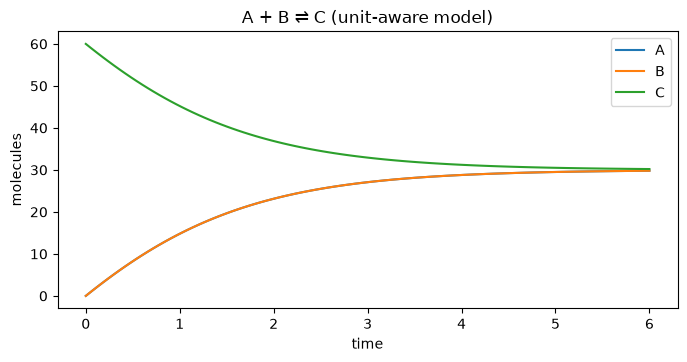

In [2]:
import matplotlib.pyplot as plt
a = ret.as_array()
plt.figure(figsize=(8,3.6))
for i,lab in enumerate(['A','B','C'],1): plt.plot(a[:,0], a[:,i], label=lab)
plt.xlabel('time'); plt.ylabel('molecules'); plt.legend(); plt.title('A + B ⇌ C (unit-aware model)'); plt.show()

## 読み取り

- `Q_(値, '単位')` で拡散係数（`um**2/s`）・半径（`um`）・速度定数（`1/(item/um**3)/s` など）に単位を付与できる。
- `run_simulation` は単位つきの時間・体積・初期値を受け取り、内部で整合的に換算する。
- `1 fL × 100 nM = 60.2 item`（≈アボガドロ数由来）のように**単位演算**もできる。
- 公式にはさらに、基準単位の変更（`getUnitRegistry(length='micrometer', time='minute')`）や
  次元不一致の検出（`check_model` / `DimensionalityMismatchError`）の例もある（出典ページ参照）。

**要点**: 単位を明示することで、拡散・濃度・速度定数の**次元ミスを機械的に防げる**。